In [10]:
!pip install pandas numpy scikit-learn seaborn matplotlib

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [12]:
data = pd.read_csv('/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv')

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [13]:
# Check the shape of the dataset
print("Shape of the dataset:", data.shape)

# Check the columns
print("Columns in the dataset:", data.columns)

# Display basic statistics
data.describe()

Shape of the dataset: (1143, 13)
Columns in the dataset: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [14]:
print("Missing values in each column:\n", data.isnull().sum())

Missing values in each column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


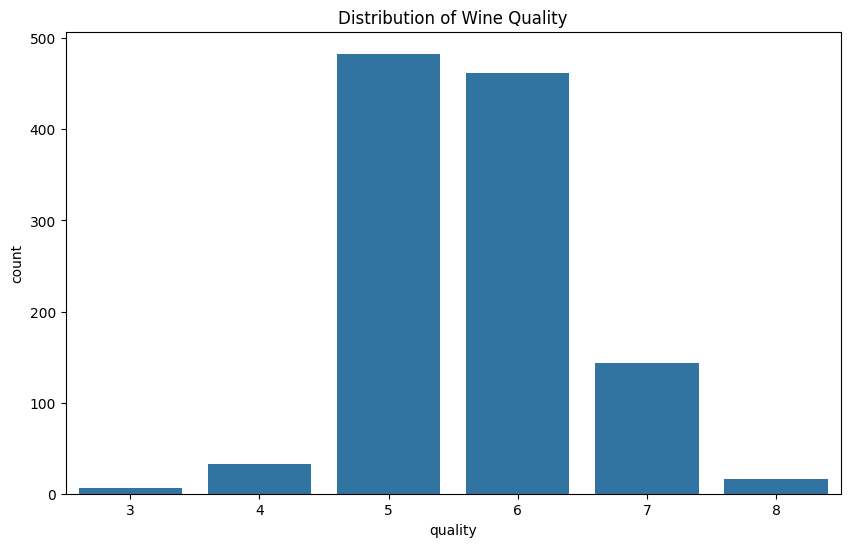

In [15]:
# Visualize the distribution of wine quality
plt.figure(figsize=(10,6))
sns.countplot(x='quality', data=data)
plt.title('Distribution of Wine Quality')
plt.show()

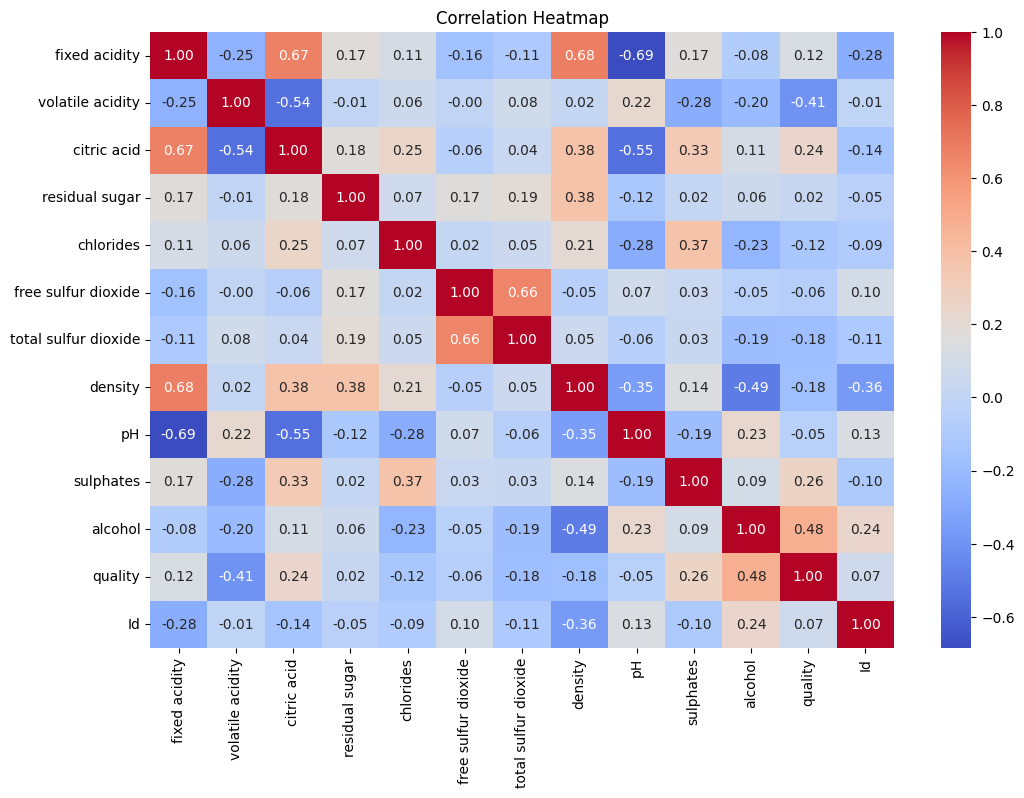

In [16]:
# Visualize the correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

# Define features and target variable
X = data.drop(columns=['quality', 'id'], errors='ignore')
y = data['quality']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Check class distribution
print("Training set class distribution:")
print(y_train.value_counts())

print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set class distribution:
quality
5    387
6    363
7    117
4     27
8     14
3      6
Name: count, dtype: int64

Testing set class distribution:
quality
6    99
5    96
7    26
4     6
8     2
Name: count, dtype: int64


In [20]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
# Predictions and evaluation
rf_predictions = rf_model.predict(X_test)

print("Random Forest Classifier Report:")
print(classification_report(y_test, rf_predictions))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Classifier Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.72      0.74      0.73        96
           6       0.63      0.68      0.65        99
           7       0.70      0.62      0.65        26
           8       0.00      0.00      0.00         2

    accuracy                           0.67       229
   macro avg       0.41      0.41      0.41       229
weighted avg       0.65      0.67      0.66       229

Random Forest Accuracy: 0.6724890829694323


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train the Random Forest model on the resampled data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)

# Predictions and evaluation
rf_predictions = rf_model.predict(X_test)

print("Random Forest Classifier Report:")
print(classification_report(y_test, rf_predictions))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Classifier Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         6
           5       0.71      0.70      0.70        96
           6       0.63      0.52      0.57        99
           7       0.49      0.77      0.60        26
           8       0.00      0.00      0.00         2

    accuracy                           0.60       229
   macro avg       0.30      0.33      0.31       229
weighted avg       0.62      0.60      0.61       229

Random Forest Accuracy: 0.6026200873362445


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
print(classification_report(y_test, rf_predictions, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         6
           5       0.71      0.70      0.70        96
           6       0.63      0.52      0.57        99
           7       0.49      0.77      0.60        26
           8       0.00      0.00      0.00         2

    accuracy                           0.60       229
   macro avg       0.30      0.33      0.31       229
weighted avg       0.62      0.60      0.61       229



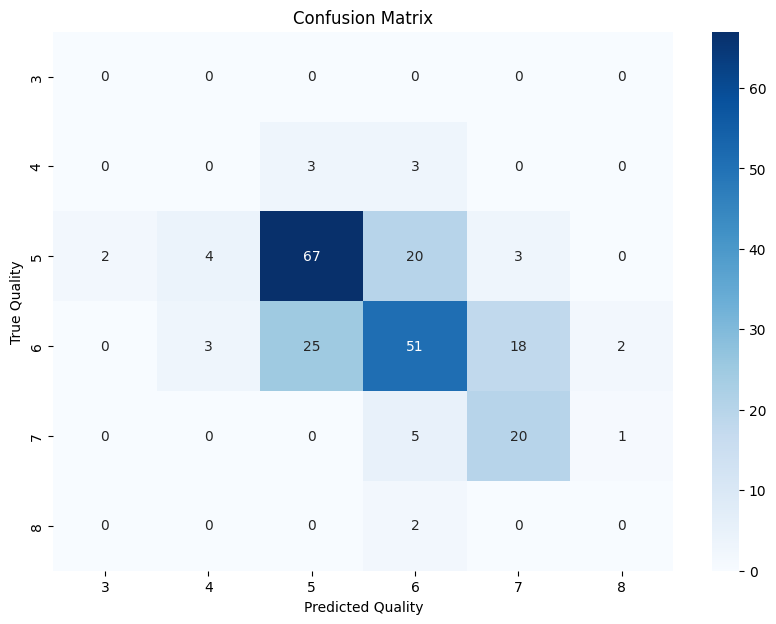

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))

plt.xlabel('Predicted Quality')
plt.ylabel('True Quality')
plt.title('Confusion Matrix')
plt.show()

In [27]:
# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and evaluation
rf_predictions = rf_model.predict(X_test)

print("Random Forest Classifier Report:")
print(classification_report(y_test, rf_predictions))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Classifier Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.73      0.75      0.74        96
           6       0.63      0.70      0.66        99
           7       0.75      0.58      0.65        26
           8       0.00      0.00      0.00         2

    accuracy                           0.68       229
   macro avg       0.42      0.40      0.41       229
weighted avg       0.66      0.68      0.67       229

Random Forest Accuracy: 0.6812227074235808


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
# Train a Stochastic Gradient Descent Classifier
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)
# Predictions and evaluation
sgd_predictions = sgd_model.predict(X_test)

print("SGD Classifier Report:")
print(classification_report(y_test, sgd_predictions))

print("SGD Accuracy:", accuracy_score(y_test, sgd_predictions))

SGD Classifier Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.74      0.33      0.46        96
           6       0.48      0.91      0.63        99
           7       0.00      0.00      0.00        26
           8       0.00      0.00      0.00         2

    accuracy                           0.53       229
   macro avg       0.25      0.25      0.22       229
weighted avg       0.52      0.53      0.47       229

SGD Accuracy: 0.5327510917030568


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# Train a Support Vector Classifier
svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)

# Predictions and evaluation
svc_predictions = svc_model.predict(X_test)

print("SVC Classifier Report:")
print(classification_report(y_test, svc_predictions))

print("SVC Accuracy:", accuracy_score(y_test, svc_predictions))

SVC Classifier Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.49      0.64      0.55        96
           6       0.50      0.53      0.51        99
           7       0.00      0.00      0.00        26
           8       0.00      0.00      0.00         2

    accuracy                           0.49       229
   macro avg       0.20      0.23      0.21       229
weighted avg       0.42      0.49      0.45       229

SVC Accuracy: 0.49344978165938863


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


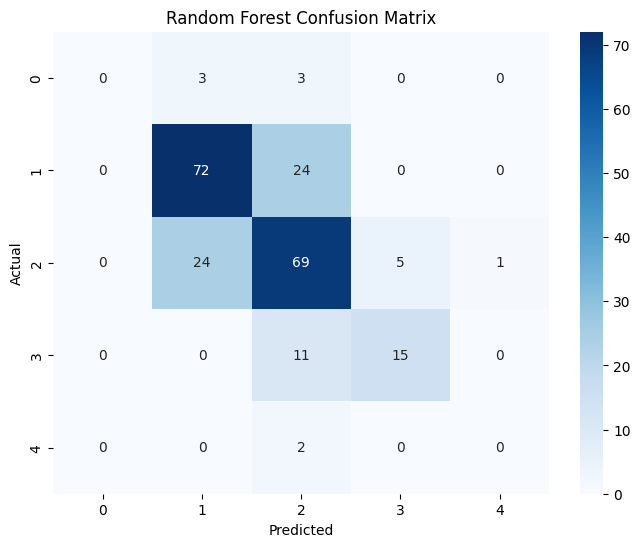

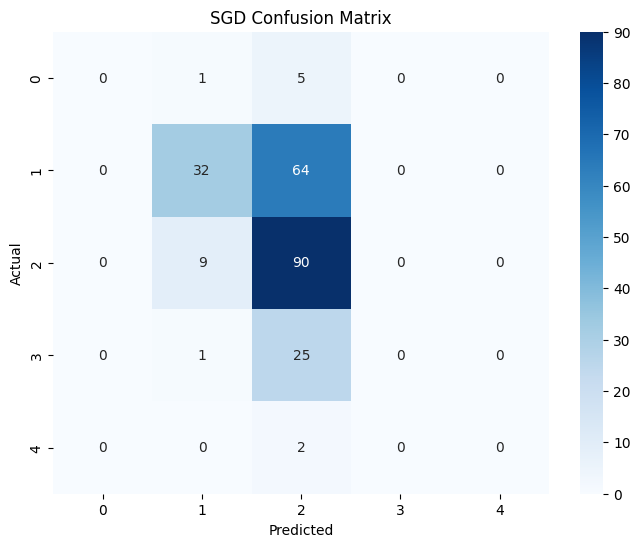

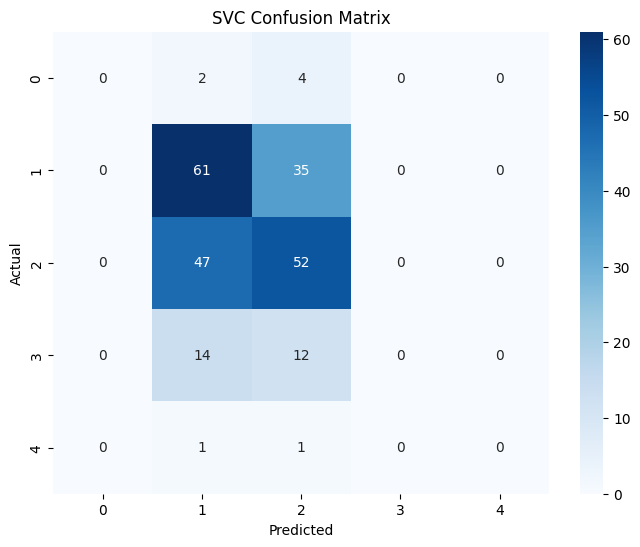

In [30]:
# Function to plot confusion matrix
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Random Forest Confusion Matrix
plot_confusion_matrix(confusion_matrix(y_test, rf_predictions),
                      title="Random Forest Confusion Matrix")

# SGD Confusion Matrix
plot_confusion_matrix(confusion_matrix(y_test, sgd_predictions),
                      title="SGD Confusion Matrix")

# SVC Confusion Matrix
plot_confusion_matrix(confusion_matrix(y_test, svc_predictions),
                      title="SVC Confusion Matrix")

In [35]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 2: Load the dataset
data = pd.read_csv("/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv")

# Step 3: Prepare features and target variable
# (Removed 'id' because it does not exist in the dataset)
X = data.drop(columns=["quality"])
y = data["quality"]

# Step 4: Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Hyperparameter tuning for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train the model
grid_search_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)

# Step 6: Predictions with the best model
rf_model = grid_search_rf.best_estimator_

rf_predictions = rf_model.predict(X_test)

print("\nRandom Forest Classifier Report:")
print(classification_report(y_test, rf_predictions))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Best parameters for Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Classifier Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.73      0.75      0.74        96
           6       0.64      0.70      0.67        99
           7       0.73      0.62      0.67        26
           8       0.00      0.00      0.00         2

    accuracy                           0.69       229
   macro avg       0.42      0.41      0.42       229
weighted avg       0.67      0.69      0.67       229

Random Forest Accuracy: 0.6855895196506551


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipykernel_55/570224518.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importances, palette="viridis")


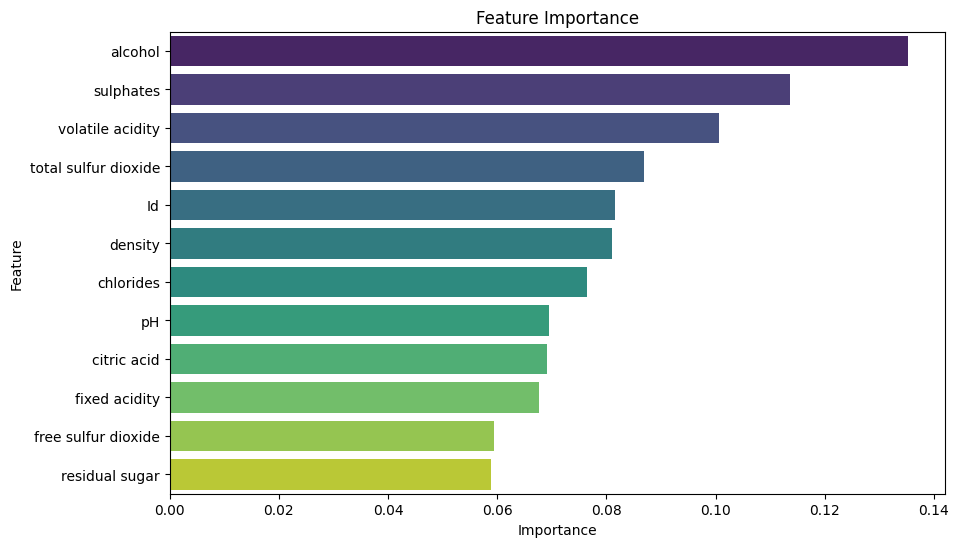

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# After running the hyperparameter tuning code
best_rf_model = grid_search_rf.best_estimator_

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importances, palette="viridis")

plt.title("Feature Importance")
plt.show()

In [37]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Random Forest using the best model
cv_scores = cross_val_score(best_rf_model, X, y, cv=5)

print("Cross-validation scores for Random Forest:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores for Random Forest: [0.44104803 0.55021834 0.6069869  0.57017544 0.52631579]
Mean cross-validation score: 0.5389489006358691


In [38]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Make sure you have trained the SGD and SVC models before this step
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)

svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train, y_train)

# Create a voting classifier
voting_clf = VotingClassifier(
    estimators=[
        ("rf", best_rf_model),   # Random Forest model
        ("sgd", sgd_model),      # SGD model
        ("svc", svc_model)       # SVC model
    ],
    voting="hard"
)

# Fit the voting classifier
voting_clf.fit(X_train, y_train)

# Make predictions
voting_predictions = voting_clf.predict(X_test)

print("Voting Classifier Accuracy:",
      accuracy_score(y_test, voting_predictions))

Voting Classifier Accuracy: 0.5676855895196506


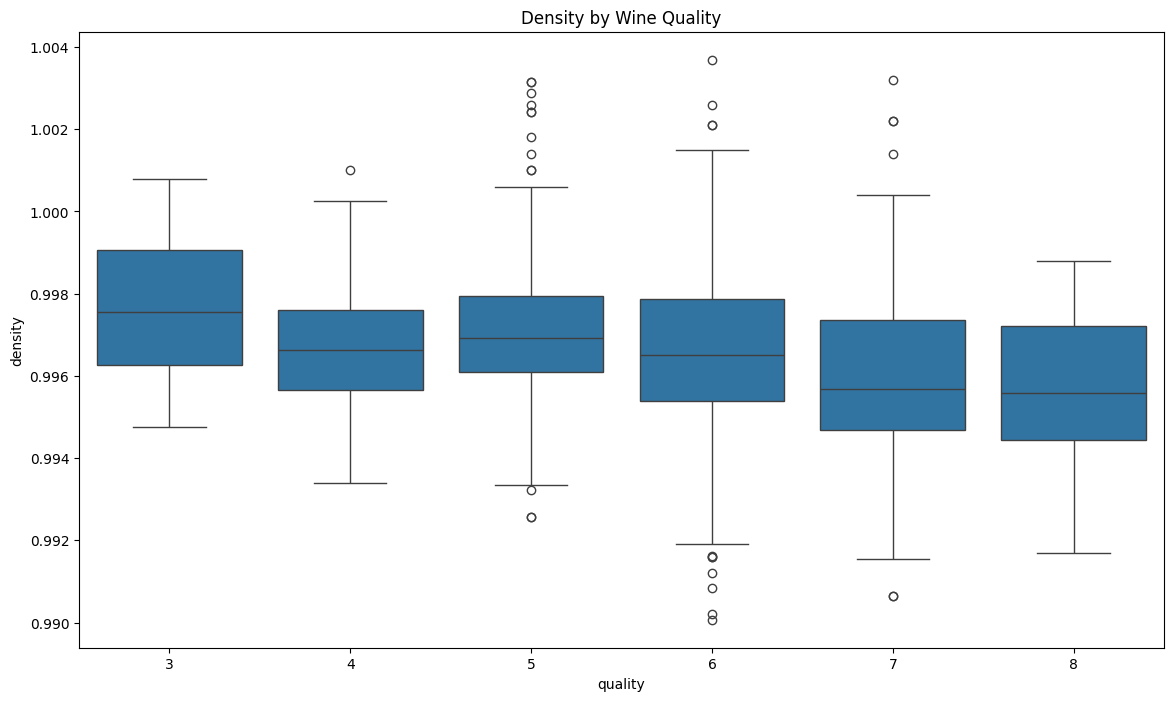

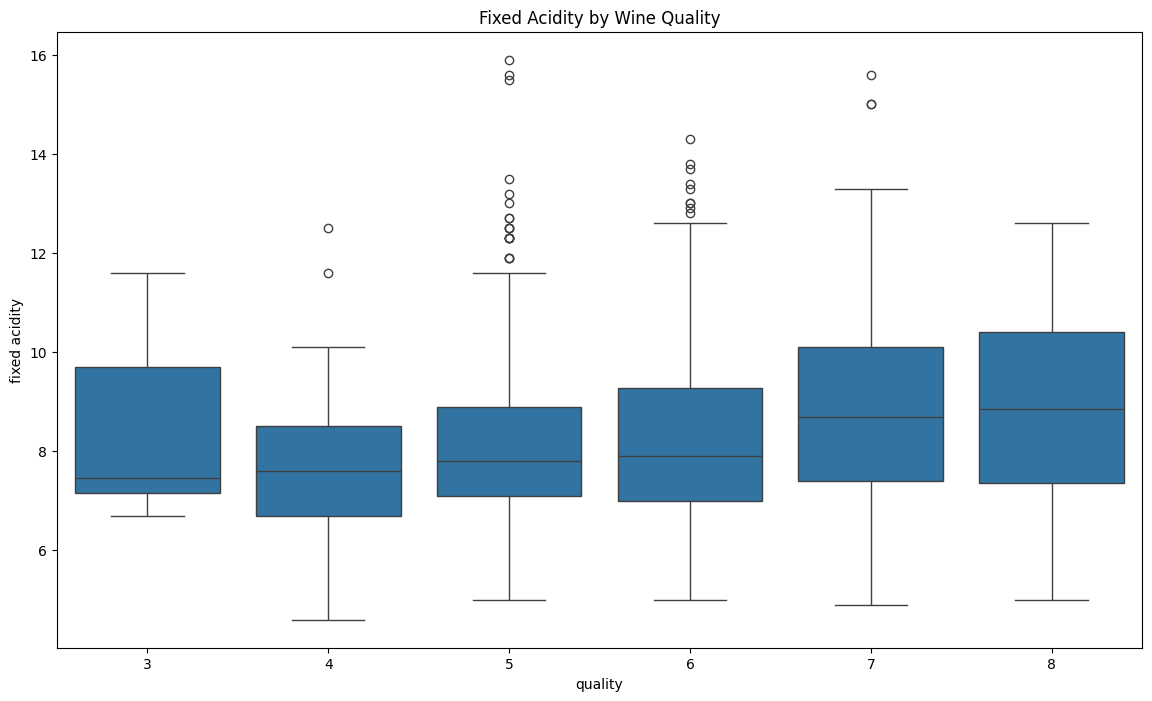

In [39]:
# Box plots for selected features
plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x='quality', y='density')
plt.title('Density by Wine Quality')
plt.show()

plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x='quality', y='fixed acidity')
plt.title('Fixed Acidity by Wine Quality')
plt.show()

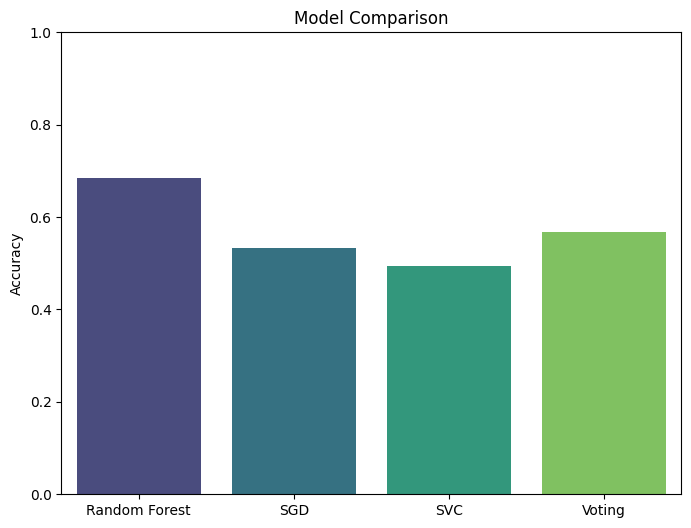

In [40]:
# Make predictions
rf_predictions = rf_model.predict(X_test)
sgd_predictions = sgd_model.predict(X_test)
svc_predictions = svc_model.predict(X_test)
voting_predictions = voting_clf.predict(X_test)

# Collecting accuracy scores
models = ['Random Forest', 'SGD', 'SVC', 'Voting']

scores = [
    accuracy_score(y_test, rf_predictions),
    accuracy_score(y_test, sgd_predictions),
    accuracy_score(y_test, svc_predictions),
    accuracy_score(y_test, voting_predictions)
]

# Plotting the results
plt.figure(figsize=(8,6))
sns.barplot(x=models, y=scores, palette='viridis', hue=models)
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

In [42]:
# Step 1: Import necessary libraries
import pandas as pd

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 2: Load the dataset
data = pd.read_csv("/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv")

# Step 3: Define features and target
X = data.drop("quality", axis=1)
y = data["quality"]

# Step 4: Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 5: Split the resampled dataset
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Step 6: Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_resampled, y_train_resampled)

# Step 7: Make predictions
rf_predictions_resampled = rf_model.predict(X_test_resampled)

# Step 8: Evaluate model performance
print("Classification Report:\n")
print(classification_report(y_test_resampled, rf_predictions_resampled))

print("Random Forest Accuracy on Resampled Data:",
      accuracy_score(y_test_resampled, rf_predictions_resampled))

Classification Report:

              precision    recall  f1-score   support

           3       1.00      1.00      1.00        97
           4       0.89      0.97      0.93        92
           5       0.79      0.69      0.74       108
           6       0.68      0.60      0.64        95
           7       0.82      0.96      0.88        96
           8       1.00      1.00      1.00        92

    accuracy                           0.87       580
   macro avg       0.86      0.87      0.86       580
weighted avg       0.86      0.87      0.86       580

Random Forest Accuracy on Resampled Data: 0.8655172413793103


In [48]:
import joblib
# Save the model
joblib.dump(rf_model, 'random_forest_model.pkl')

# Load the model
loaded_rf_model = joblib.load('random_forest_model.pkl')

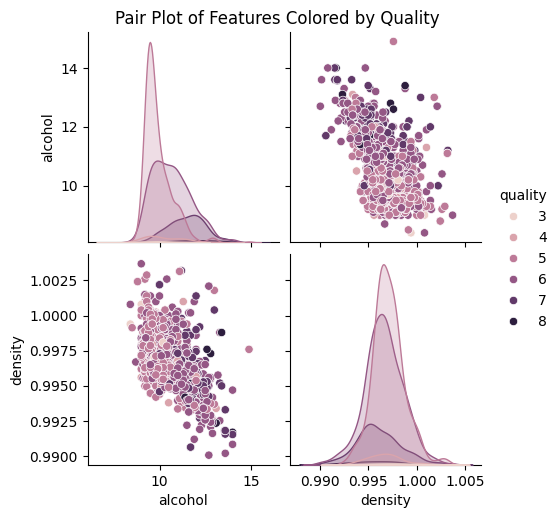

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pair plot for selected features colored by wine quality
g = sns.pairplot(data=data, hue='quality', vars=['alcohol', 'density'], diag_kind='kde')

# Add title
g.fig.suptitle('Pair Plot of Features Colored by Quality', y=1.02)

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


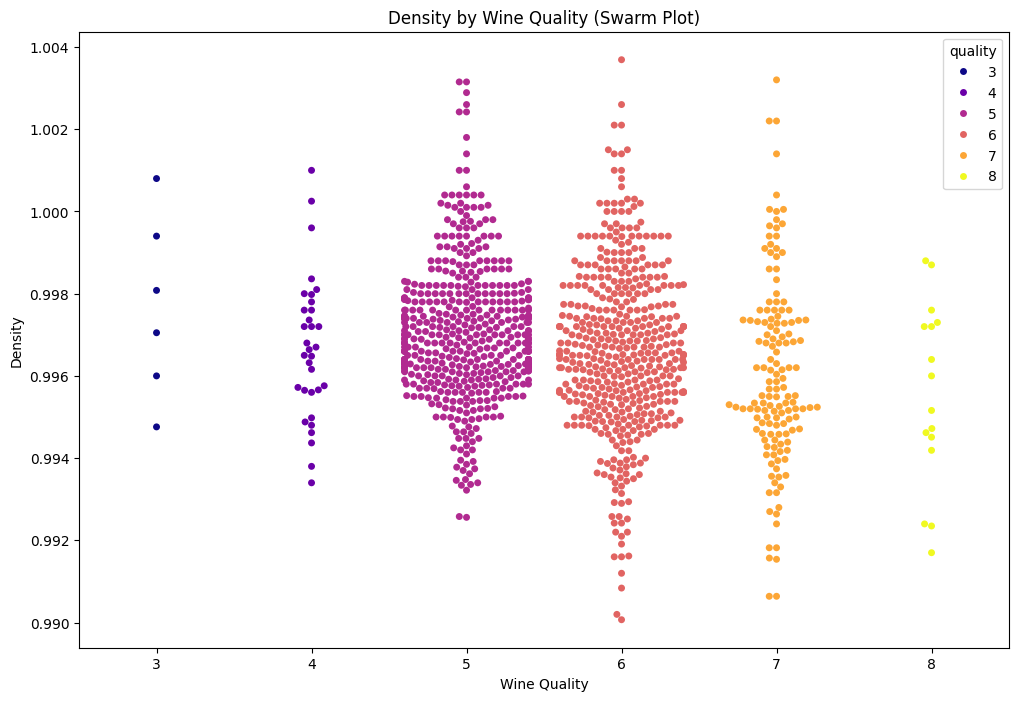

In [52]:
plt.figure(figsize=(12, 8))
sns.swarmplot(x='quality', y='density', data=data, hue='quality', palette='plasma')
plt.title('Density by Wine Quality (Swarm Plot)')
plt.xlabel('Wine Quality')
plt.ylabel('Density')
plt.show()

/tmp/ipykernel_55/2320725459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='fixed acidity', data=data, palette='coolwarm')


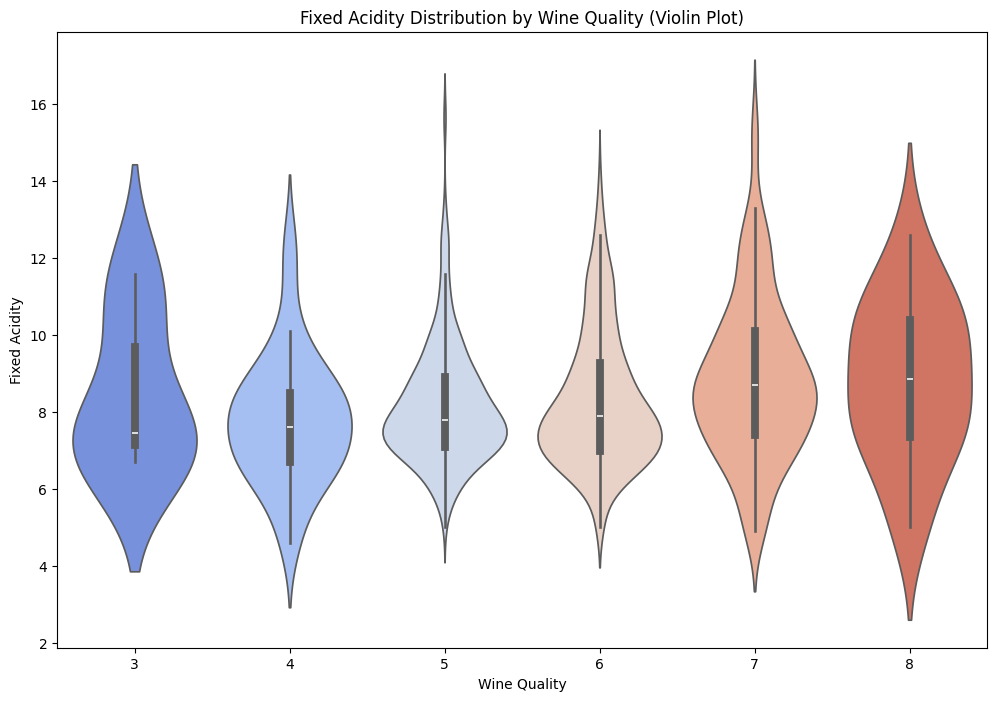

In [53]:
plt.figure(figsize=(12, 8))
sns.violinplot(x='quality', y='fixed acidity', data=data, palette='coolwarm')
plt.title('Fixed Acidity Distribution by Wine Quality (Violin Plot)')
plt.xlabel('Wine Quality')
plt.ylabel('Fixed Acidity')
plt.show()

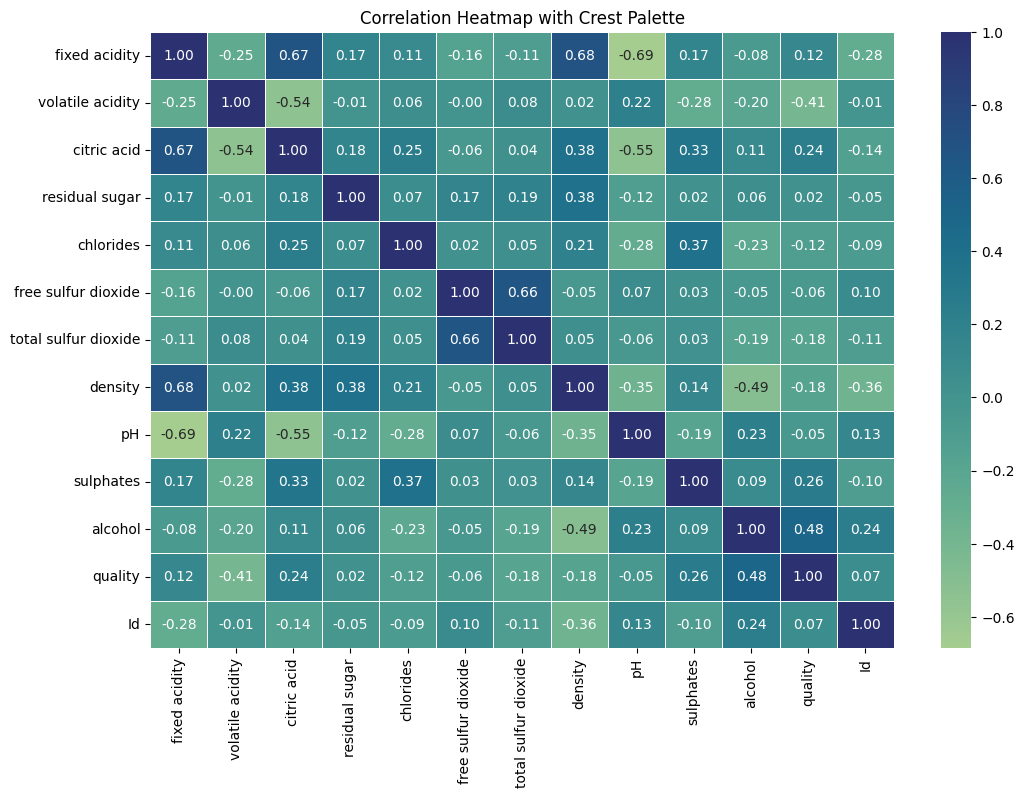

In [54]:
plt.figure(figsize=(12, 8))
correlation = data.corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='crest', linewidths=.5)
plt.title('Correlation Heatmap with Crest Palette')
plt.show()

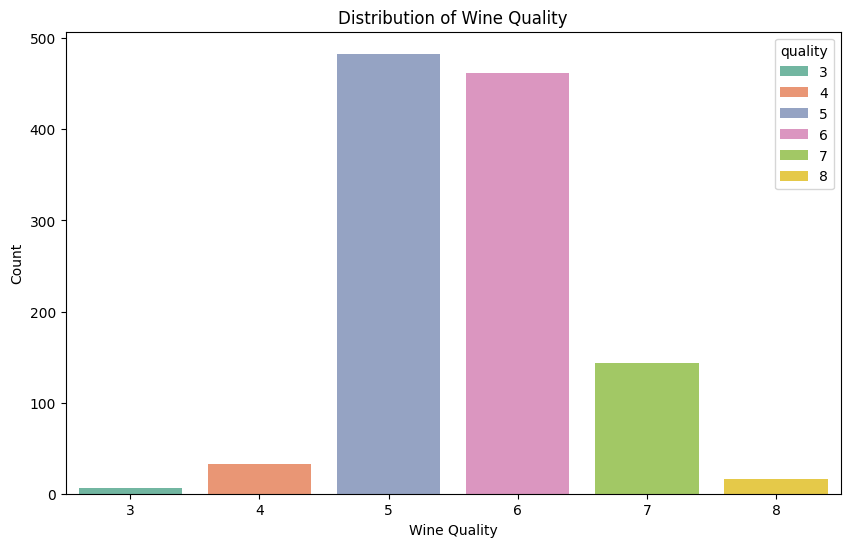

In [55]:
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=data, hue='quality', palette='Set2')

plt.title('Distribution of Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_55/2395310832.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Wine Quality')


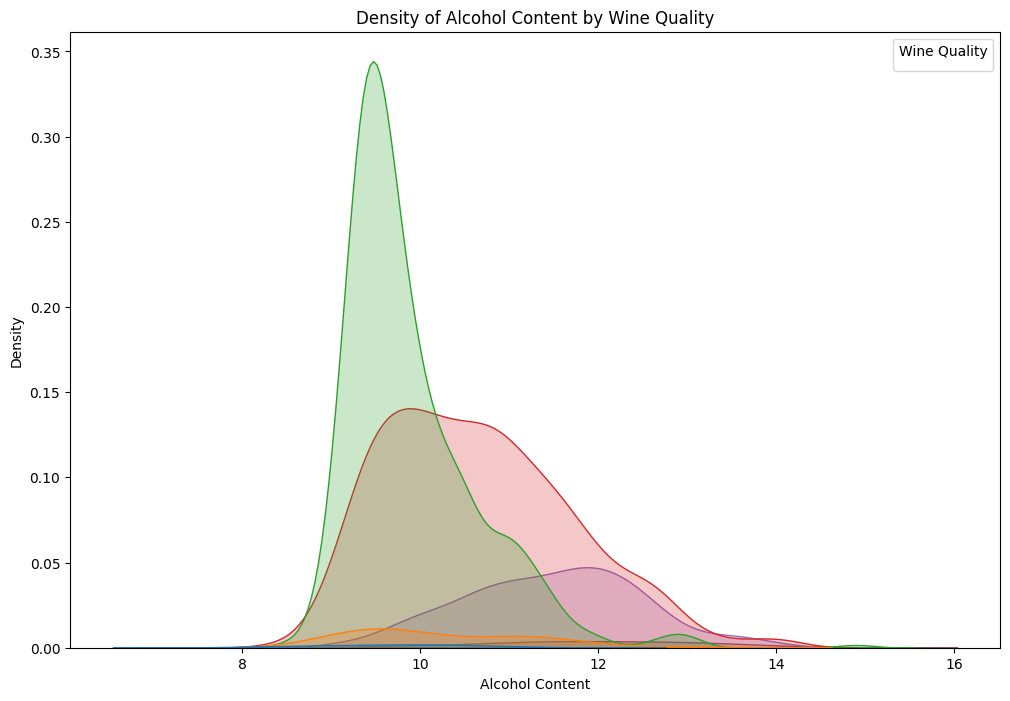

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.kdeplot(
    data=data,
    x='alcohol',
    hue='quality',
    palette='tab10',
    fill=True
)

plt.title('Density of Alcohol Content by Wine Quality')
plt.xlabel('Alcohol Content')
plt.ylabel('Density')
plt.legend(title='Wine Quality')

plt.show()

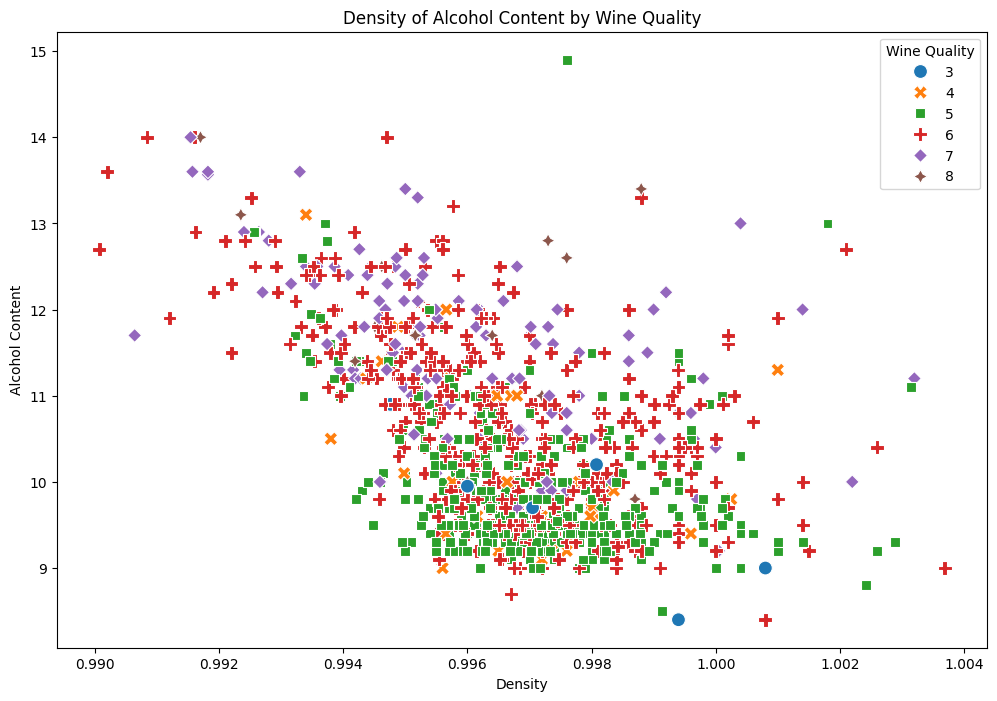

In [59]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='density', y='alcohol', hue='quality',
            palette='tab10', style='quality', s=100)

plt.title('Density of Alcohol Content by Wine Quality')
plt.xlabel('Density')
plt.ylabel('Alcohol Content')
plt.legend(title='Wine Quality')
plt.show()

<Figure size 1200x600 with 0 Axes>

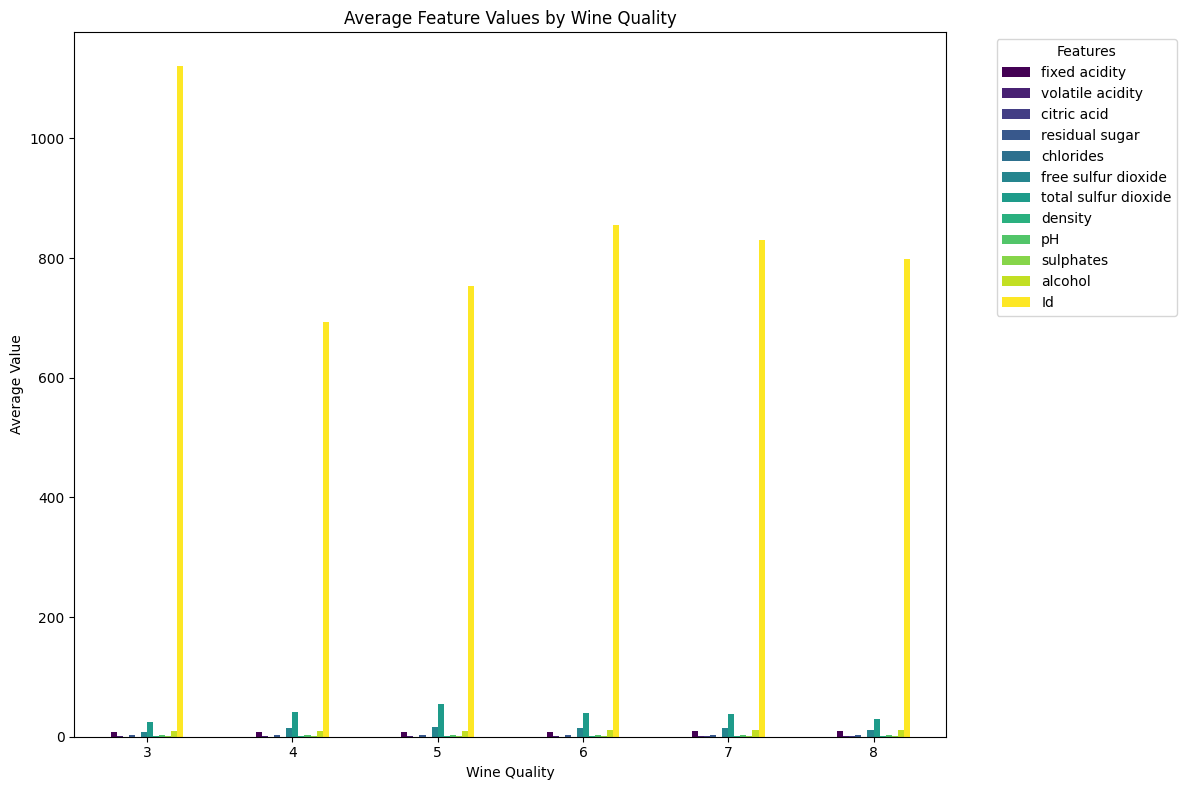

In [58]:
average_features = data.groupby('quality').mean()

plt.figure(figsize=(12, 6))
average_features.plot(kind='bar', colormap='viridis', figsize=(12, 8))

plt.title('Average Feature Values by Wine Quality')
plt.ylabel('Average Value')
plt.xlabel('Wine Quality')
plt.xticks(rotation=0)

plt.legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [60]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


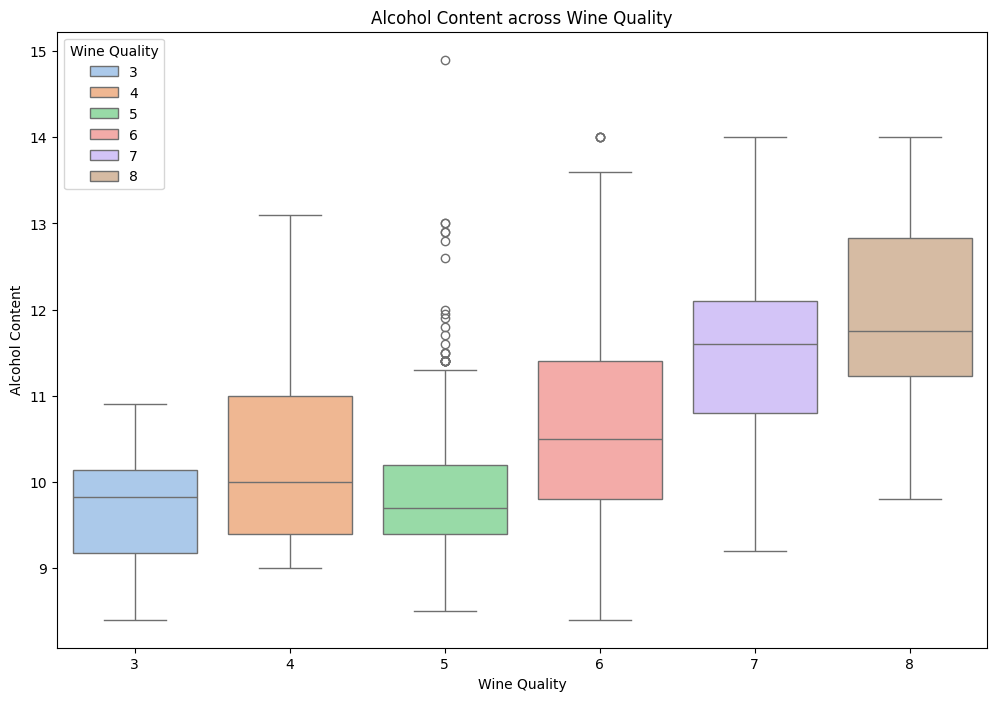

In [62]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=data, x='quality', y='alcohol', hue='quality',
            palette='pastel')

plt.title('Alcohol Content across Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Alcohol Content')
plt.legend(title='Wine Quality')
plt.show()

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

Text(6.195986111111113, 0.5, 'Density')

<Figure size 1200x600 with 0 Axes>

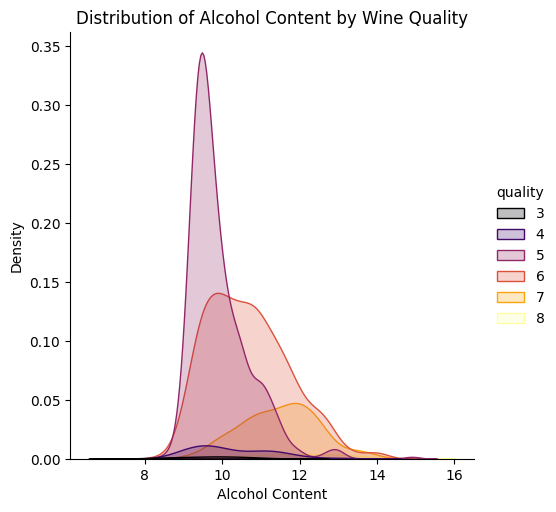

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv')
print(df.head())

# Distribution plot for alcohol
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.displot(df, x='alcohol', hue='quality', kind='kde', palette='inferno', fill=True)
plt.title('Distribution of Alcohol Content by Wine Quality')
plt.xlabel('Alcohol Content')
plt.ylabel('Density')


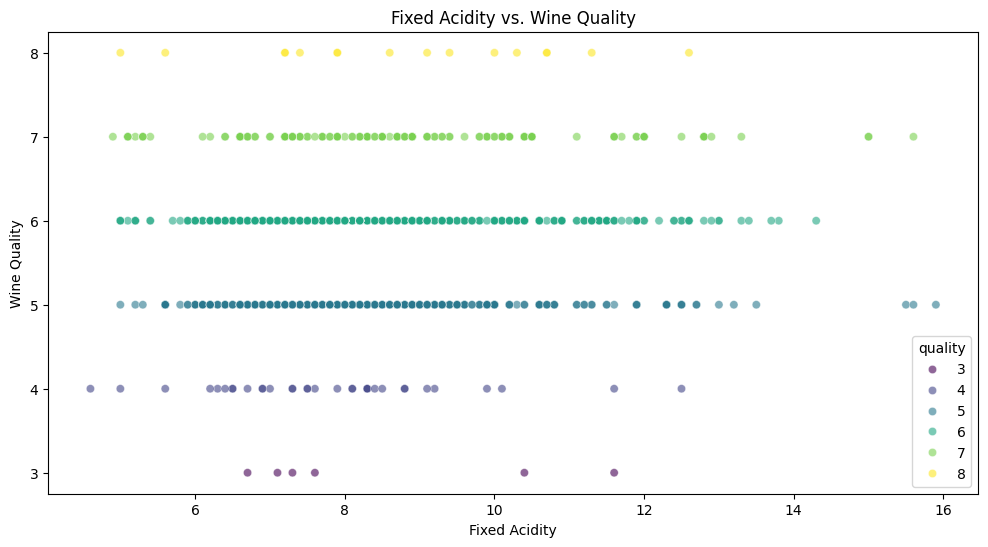

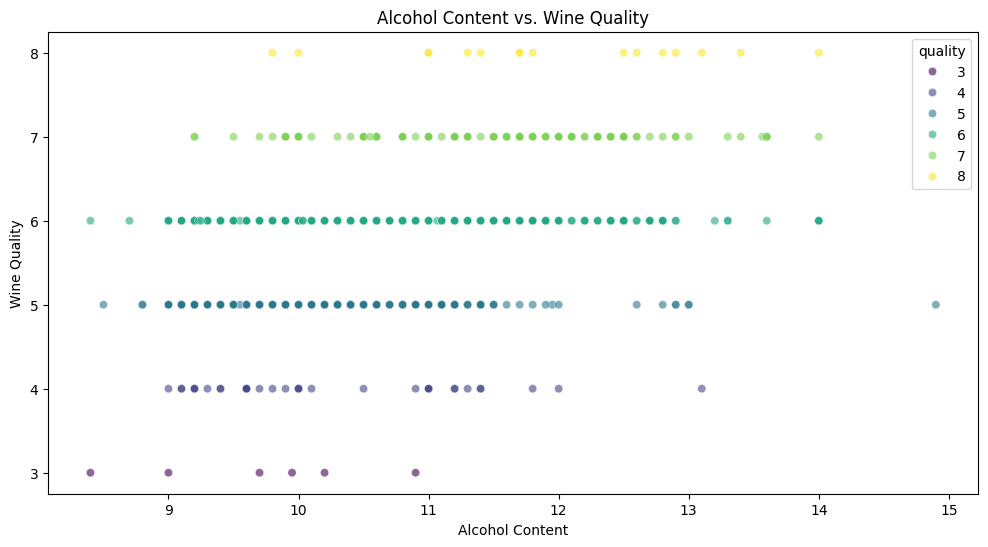

In [66]:
# Scatter plots for fixed acidity vs. quality
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='fixed acidity', y='quality', hue='quality', palette='viridis', alpha=0.6)
plt.title('Fixed Acidity vs. Wine Quality')
plt.xlabel('Fixed Acidity')
plt.ylabel('Wine Quality')

# Scatter plots for alcohol vs. quality
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='viridis', alpha=0.6)
plt.title('Alcohol Content vs. Wine Quality')
plt.xlabel('Alcohol Content')
plt.ylabel('Wine Quality')

plt.show()